# Universe method

by Reece Colclough and Oleg Glotov

In [22]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sbn

#used to check for stationarity in the time series
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress

# ignore warnings for the KPSS test 
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

In order to find the best stationarity pair, we need to utilize both the ADF test and the KPSS test. Both tests have their drawback and potential issue, therefore, a pair of stocks that performs well in both tests are likely to be more stationary. We construct this test statistic in the following way:
$$\text{Stationarity Score} = - \text{KPSS Stats} - \text{ADF Test}$$
since a low KPSS stats and a low ADF stats both indicates stronger evidence of stationarity (how we weight these two stats is subjective to improvement)

In [23]:
def check_stationarity(series, alpha):

    # h_0 is that the series has a unit root-> if so, likely non-stationarity
    result_adf = adfuller(series,regression='ct')
    p_val = result_adf[1]
    if p_val < alpha:
        # reject, likely trend stationary
        print("ADF test: p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("ADF test: p-val=", p_val, "-> Conclusion: likely non-stationarity")

    #return result_adf[1]

     #print("----------------------------------------------------------------")
    
    # Since we are focusing on the trend stationarity, we will use the KPSS test
    result_kpss = kpss(series, regression='ct')
    kpss_stat = result_kpss[0]
    p_val = result_kpss[1]
    if p_val > alpha:
        #reject, likely stationary
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely trend stationary")
    else:
        print("KPSS test: KPSS stats:", kpss_stat, "p-val=", p_val, "-> Conclusion: likely not trend stationary")
    
    station_score = -kpss_stat - result_adf[0]
    return station_score


In [24]:
def methodology_cointegration(stk1, stk2):
    diff = abs(stk1["Adj Close"] - stk2["Adj Close"])

    time = np.arange(len(diff))
    reg = linregress(time, diff)
    #line = reg.intercept + reg.slope*time
    #new_series = diff - line

    return check_stationarity(diff, 0.05), reg.slope


def methodology(stk1, stk2):
    # Calculate correlation between the two stocks' adjusted close prices
    correlation = np.corrcoef(stk1["Adj Close"], stk2["Adj Close"])[0,1]
    
    # Calculate the slope between the two stocks
    time = np.arange(len(stk1["Adj Close"]))
    reg = linregress(time, stk2["Adj Close"] - stk1["Adj Close"])
    
    return correlation, reg.slope

In [25]:
def download_data(stk):

    # start date because of moderna listing in 2018 December and yfinance data delay

    start_date = "2024-01-16"
    end_date = "2025-01-15"

    stk_data = yf.download(stk,start=start_date,end=end_date)

    return stk_data

In [26]:
# Will plot 2 equities

# universe = ["MSFT", "MRNA",]

# stk_data = []
# for stk in universe:
#     stk_data.append(download_data(stk))

# plt.figure()
# for x in stk_data:
#     plt.plot(x["Adj Close"], label="stk1")

# plt.legend()
# plt.title("stks Price Plot")
# plt.show()

In [27]:
# Download Data

# universe = ["AAPL","AAL","AMD","AMZN","BA","BABA","BAC","C","CAT","COST","CSCO","CVX","DIS","DLR","EQIX","F","GM","GOOGL","GS","IBM","INTC","JNJ","JPM","KO","LMT","LULU","META","MPC","MRK","MRNA","MSFT","MU","NFLX","NKE","NVDA","PFE","TSLA","VZ","WFC","WM","XOM","SCHW","RIOT",]

universe = ["^VIX", "LNF.TO", "TGT", "ANET", "BLDR", "EQT", "TLT", "GC=F", "HG=F", "CL=F", "NKE", "^GSPTSE" , "CADUSD=X", "^TNX", "XBB.TO", "ACO-X.TO", "WFG.TO","HBM.TO","CSH-UN.TO","L.TO","AGG","SPY","SPSB","CG","APO","AER","MA","AMSF","MP","DOLE","AAPL","EA","AMAT","VEEV","TMUS","GSL","TEX","CEG","WSC","ISRG","BLBD" ]

stk_data = []
for stk in universe:
    stk_data.append(download_data(stk))

# Align all dataframes on their index
aligned_data = []
for df in stk_data:
    # Reset index to make date a column
    df_reset = df.reset_index()
    aligned_data.append(df_reset)

# Find common dates across all dataframes
common_dates = set(aligned_data[0]['Date'])
for df in aligned_data[1:]:
    common_dates = common_dates.intersection(set(df['Date']))

# Filter each dataframe to only include common dates
filtered_data = []
for df in aligned_data:
    filtered = df[df['Date'].isin(common_dates)].sort_values('Date').set_index('Date')
    filtered_data.append(filtered)

stk_data = filtered_data  # Replace original data with aligned data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [28]:
for stk in stk_data:
    print(stk.shape)

(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)
(246, 6)


In [29]:
# normalize the stock price for all the stocks so that the first date's price is 1

for i in range(len(stk_data)):
    stk_data[i]["Adj Close"] = stk_data[i]["Adj Close"]/stk_data[i]["Adj Close"][0]

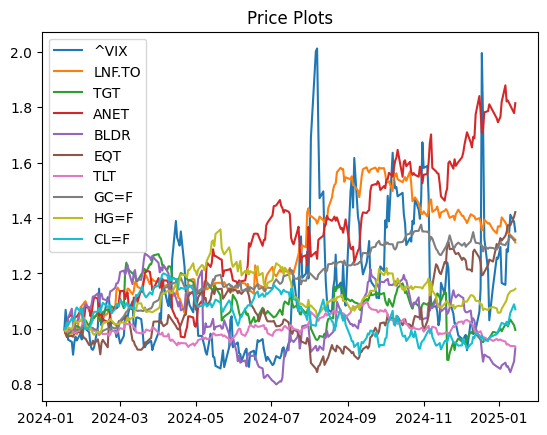

In [30]:
plt.figure()
i = 0
for x in stk_data[:10]:
    plt.plot(x["Adj Close"], label=universe[i])
    i+=1

plt.legend()
plt.title("Price Plots")
plt.savefig('Stock Prices.png', dpi = 1500)
# plt.show()

In [31]:
# initialize cov-matrix
data = np.random.rand(len(universe), len(universe))
slope = np.random.rand(len(universe), len(universe))
stockNum = len(universe)


# Calculate the stationary properties
cov = np.zeros((stockNum, stockNum))
for i in range(stockNum):
    for j in range(stockNum):
        if (i == j):
            data[i,j] = 1
            # set the slope to 0 if the stock is the same
            slope[i,j] = 0
        else:
            print(universe[i]+universe[j])
            
            data[i,j],slope[i,j] = methodology(stk_data[i],stk_data[j])

^VIXLNF.TO
^VIXTGT
^VIXANET
^VIXBLDR
^VIXEQT
^VIXTLT
^VIXGC=F
^VIXHG=F
^VIXCL=F
^VIXNKE
^VIX^GSPTSE
^VIXCADUSD=X
^VIX^TNX
^VIXXBB.TO
^VIXACO-X.TO
^VIXWFG.TO
^VIXHBM.TO
^VIXCSH-UN.TO
^VIXL.TO
^VIXAGG
^VIXSPY
^VIXSPSB
^VIXCG
^VIXAPO
^VIXAER
^VIXMA
^VIXAMSF
^VIXMP
^VIXDOLE
^VIXAAPL
^VIXEA
^VIXAMAT
^VIXVEEV
^VIXTMUS
^VIXGSL
^VIXTEX
^VIXCEG
^VIXWSC
^VIXISRG
^VIXBLBD
LNF.TO^VIX
LNF.TOTGT
LNF.TOANET
LNF.TOBLDR
LNF.TOEQT
LNF.TOTLT
LNF.TOGC=F
LNF.TOHG=F
LNF.TOCL=F
LNF.TONKE
LNF.TO^GSPTSE
LNF.TOCADUSD=X
LNF.TO^TNX
LNF.TOXBB.TO
LNF.TOACO-X.TO
LNF.TOWFG.TO
LNF.TOHBM.TO
LNF.TOCSH-UN.TO
LNF.TOL.TO
LNF.TOAGG
LNF.TOSPY
LNF.TOSPSB
LNF.TOCG
LNF.TOAPO
LNF.TOAER
LNF.TOMA
LNF.TOAMSF
LNF.TOMP
LNF.TODOLE
LNF.TOAAPL
LNF.TOEA
LNF.TOAMAT
LNF.TOVEEV
LNF.TOTMUS
LNF.TOGSL
LNF.TOTEX
LNF.TOCEG
LNF.TOWSC
LNF.TOISRG
LNF.TOBLBD
TGT^VIX
TGTLNF.TO
TGTANET
TGTBLDR
TGTEQT
TGTTLT
TGTGC=F
TGTHG=F
TGTCL=F
TGTNKE
TGT^GSPTSE
TGTCADUSD=X
TGT^TNX
TGTXBB.TO
TGTACO-X.TO
TGTWFG.TO
TGTHBM.TO
TGTCSH-UN.TO
TGTL.TO
TGTAGG
TGTSPY
TGTSPSB

In [32]:
# Create a heatmap of slope using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map_slope = sbn.heatmap(slope, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Slope for Correlation Pairs")

plt.savefig('HeatMap_slope.png')
plt.show()

In [33]:
# Create a heatmap using Matplotlib
plt.figure(figsize=(stockNum, stockNum),dpi=250)
heat_map = sbn.heatmap(data, xticklabels=universe, yticklabels=universe, annot=True, cmap="mako")
plt.title("Heat Map of Correlation Scores for Pairs")

plt.savefig('HeatMap_correlation_score.png')
plt.show()

In [34]:
df = pd.DataFrame(data = data)
df.columns = universe

print("Data Frame")
print(df)
print()

# Get data below diagonal and sort
sol = (df.where(np.triu(np.ones(df.shape), k=1).astype(bool)).stack().sort_values(ascending=False).reset_index())

mapping = {i: universe[i] for i in range(len(universe))}

# Replace numbers in column 'A' with the corresponding index string
sol['level_0'] = sol['level_0'].map(mapping)

Data Frame
        ^VIX    LNF.TO       TGT      ANET      BLDR       EQT       TLT  \
0   1.000000  0.559000 -0.086128  0.333994  0.015583 -0.153199  0.253869   
1   0.559000  1.000000 -0.118072  0.741672  0.042877  0.057481  0.618710   
2  -0.086128 -0.118072  1.000000 -0.404361  0.565706 -0.331019 -0.068918   
3   0.333994  0.741672 -0.404361  1.000000 -0.275155  0.544982  0.181332   
4   0.015583  0.042877  0.565706 -0.275155  1.000000 -0.252727  0.150793   
5  -0.153199  0.057481 -0.331019  0.544982 -0.252727  1.000000 -0.507049   
6   0.253869  0.618710 -0.068918  0.181332  0.150793 -0.507049  1.000000   
7   0.494290  0.848429 -0.180975  0.868680 -0.147982  0.426711  0.243271   
8  -0.107402  0.087234  0.231628  0.123972 -0.243596  0.241238 -0.166233   
9  -0.346571 -0.665332  0.484540 -0.593321  0.012256 -0.246069 -0.463426   
10 -0.471303 -0.690482  0.296948 -0.766505  0.381955 -0.284486 -0.198893   
11  0.355721  0.787927 -0.285732  0.912887 -0.033571  0.577993  0.178881   
1

In [39]:
print(sol.head(15))
print()
n = 15
print(f"last {n} rows")
print()
print(sol.tail(n))

      Stock 1    Stock 2  Correlation     Slope
0   CSH-UN.TO       SPSB     0.975031 -0.001651
1    ACO-X.TO  CSH-UN.TO     0.975001  0.000126
2    ACO-X.TO       SPSB     0.973667 -0.001525
3      XBB.TO       SPSB     0.968780 -0.000077
4        TMUS       ISRG     0.965121 -0.000019
5        SPSB       ISRG     0.959693  0.001967
6         SPY       ISRG     0.959092  0.001164
7        ANET        SPY     0.957574 -0.002064
8    ACO-X.TO       TMUS     0.956961  0.000461
9        L.TO        SPY     0.956934 -0.000723
10  CSH-UN.TO       ISRG     0.955037  0.000316
11  CSH-UN.TO       TMUS     0.954426  0.000335
12     LNF.TO       DOLE     0.952054 -0.000146
13    ^GSPTSE        SPY     0.951958  0.000179
14   ACO-X.TO       ISRG     0.950394  0.000442

last 15 rows

      Stock 1   Stock 2  Correlation     Slope
805       AER       WSC    -0.766249 -0.002322
806      ANET       NKE    -0.766505 -0.004305
807      CL=F    XBB.TO    -0.773097  0.000991
808      CL=F      TMUS    -0

In [36]:
# add a new column to the dataframe
sol['slope'] = sol.apply(lambda row: slope[universe.index(row['level_0'])][universe.index(row['level_1'])], axis=1)
sol.columns = ['Stock 1', 'Stock 2', 'Correlation', 'Slope']
# display the top 30 pairs with positive slope
print()
print("Top 30 Pairs with Positive Slope")
print()
print(sol[sol['Slope'] > 0].head(30))


Top 30 Pairs with Positive Slope

      Stock 1    Stock 2  Correlation     Slope
1    ACO-X.TO  CSH-UN.TO     0.975001  0.000126
5        SPSB       ISRG     0.959693  0.001967
6         SPY       ISRG     0.959092  0.001164
8    ACO-X.TO       TMUS     0.956961  0.000461
10  CSH-UN.TO       ISRG     0.955037  0.000316
11  CSH-UN.TO       TMUS     0.954426  0.000335
13    ^GSPTSE        SPY     0.951958  0.000179
14   ACO-X.TO       ISRG     0.950394  0.000442
15    ^GSPTSE       TMUS     0.949896  0.001361
17    ^GSPTSE  CSH-UN.TO     0.945090  0.001027
18    ^GSPTSE   ACO-X.TO     0.944748  0.000901
19     XBB.TO  CSH-UN.TO     0.938495  0.001574
20     XBB.TO   ACO-X.TO     0.938210  0.001449
22    ^GSPTSE       ISRG     0.936158  0.001343
23       L.TO       ISRG     0.935754  0.000440
24     XBB.TO       ISRG     0.935116  0.001890
25        SPY       TMUS     0.933048  0.001182
28    ^GSPTSE       L.TO     0.929788  0.000902
29       GC=F       L.TO     0.929482  0.000343
30   